In [ ]:
# Figure S6






In [1]:

import netCDF4 as nc4
import numpy as np
import glob as glob
import matplotlib.pyplot as plt
from scipy import stats



import glob as glob
import os
from collections import OrderedDict
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
import matplotlib.pyplot as plt
import matplotlib as mpl
from pylab import *; 
import cartopy
import cartopy.crs as ccrs
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300



from datetime import datetime, timedelta

def convert_days_to_date(days_since_origin, origin_date_str="0001-01-01"):
    """
    Converts a number of days since a specified origin date to an actual date.

    Args:
        days_since_origin (int or float): The number of days since the origin.
        origin_date_str (str): The origin date in 'YYYY-MM-DD' format.

    Returns:
        datetime.datetime: The calculated actual date and time.
    """
    # 1. Define the origin date as a datetime object
    origin_date = datetime.strptime(origin_date_str, "%Y-%m-%d")

    # 2. Create a timedelta object from the number of days
    delta = timedelta(days=days_since_origin)

    # 3. Add the timedelta to the origin date to get the resulting date
    actual_date = origin_date + delta

    return actual_date


ERROR 1: PROJ: proj_create_from_database: Open of /curc/sw/conda_env/atoc-2025/share/proj failed


In [2]:

data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'


these_cases=['fosi_ip_46p8_01_alluv','fosi_ip_46p8_01_ctluv']
these_variables=['photoC_TOT','photoC_sp','photoC_diat','photoC_cocco']

files={}
for case in these_cases: # these files need to be processed and in their proper place
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.000502-*.nc'))[:]

        
files['fosi_ip_46p8_01_alluv']

{'photoC_TOT': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/fosi_ip_46p8_01_alluv/fosi_ip_46p8_01_alluv.pop.h.photoC_TOT.000502-002101.nc'],
 'photoC_sp': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/fosi_ip_46p8_01_alluv/fosi_ip_46p8_01_alluv.pop.h.photoC_sp.000502-002101.nc'],
 'photoC_diat': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/fosi_ip_46p8_01_alluv/fosi_ip_46p8_01_alluv.pop.h.photoC_diat.000502-002101.nc'],
 'photoC_cocco': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/fosi_ip_46p8_01_alluv/fosi_ip_46p8_01_alluv.pop.h.photoC_cocco.000502-002101.nc']}

In [3]:

example_file = files[case]['photoC_TOT'][0]
NMONTHS=17*12


extract = nc4.Dataset(example_file,'r')
TAREA = extract.variables['TAREA'][0]*(100**-2)
z_t_150m = extract.variables['z_t_150m'][:]*(0.01)
dz = extract.variables['dz'][0]*(0.01) # this should be DELTA Z not z_t_150m
dz = dz*0 + 1 
TLAT = extract.variables['TLAT'][:]


extract_biome=nc4.Dataset('/projects/joco6825/fay_biomes_POP.nc','r')
biome_mask = extract_biome.variables['fay_biomes'][:].T
TAREA_biome6 = np.array(TAREA)

#TAREA_biome6[biome_mask != 16] = 0.0 # set TAREA to 0 when biome_mask is 6 (eastern equatorial Pacific)
#TAREA_biome6[TAREA_biome6>9e35] = 0.0 # in case fill values fail to be registered


threshold_date = datetime.strptime('0005-01-01', "%Y-%m-%d")


scale_factor = (1000**-1) * (12.011) * (86400) * (365) * (1e-15)

VARIABLES=['photoC_TOT','photoC_sp','photoC_diat','photoC_cocco']
#VARIABLES=['photoC_TOT']
if True:
 data={};
 for case in these_cases:
     print(case)
     data[case]={}
     for VAR in VARIABLES:
         print(VAR)
         data[case][VAR]=np.zeros((NMONTHS,len(z_t_150m)))
         mo=0
         for fi in files[case][VAR][:]:
             extract = nc4.Dataset(fi,'r')
             dates = extract.variables['time'][:]
             for t in range(len(dates)):
                 # convert to datetime days since 0000-01-01 00:00:00
                 result_date = convert_days_to_date(dates[t])
                 if result_date > threshold_date: # put them on the same time axis
                     tempdata = extract.variables[VAR][t]
                     for lev in range(len(z_t_150m)):
                         data[case][VAR][mo][lev] = np.nansum(tempdata[lev]*TAREA_biome6*dz[lev]*scale_factor)#,weights=TAREA_biome6)
                     mo=mo+1 
                    
                    
print('DONE') # blanca has been hanging recently, added this to confirm block of code is finished 

fosi_ip_46p8_01_alluv
photoC_TOT
photoC_sp
photoC_diat
photoC_cocco
fosi_ip_46p8_01_ctluv
photoC_TOT
photoC_sp
photoC_diat
photoC_cocco
DONE


/tmp/ipykernel_3694040/2203081363.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(string, num)    # PiYG


Axes(0.125,0.53;0.352273x0.35)
Axes(0.547727,0.53;0.352273x0.35)
Axes(0.125,0.11;0.352273x0.35)
Axes(0.547727,0.11;0.352273x0.35)


/tmp/ipykernel_3694040/2203081363.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  cbar1.set_label('$\Delta$NPP (Pg C yr$^{-1}$ m$^{-1}$)',fontsize=COLORBARLABEL_FONTSIZE); fig.tight_layout()


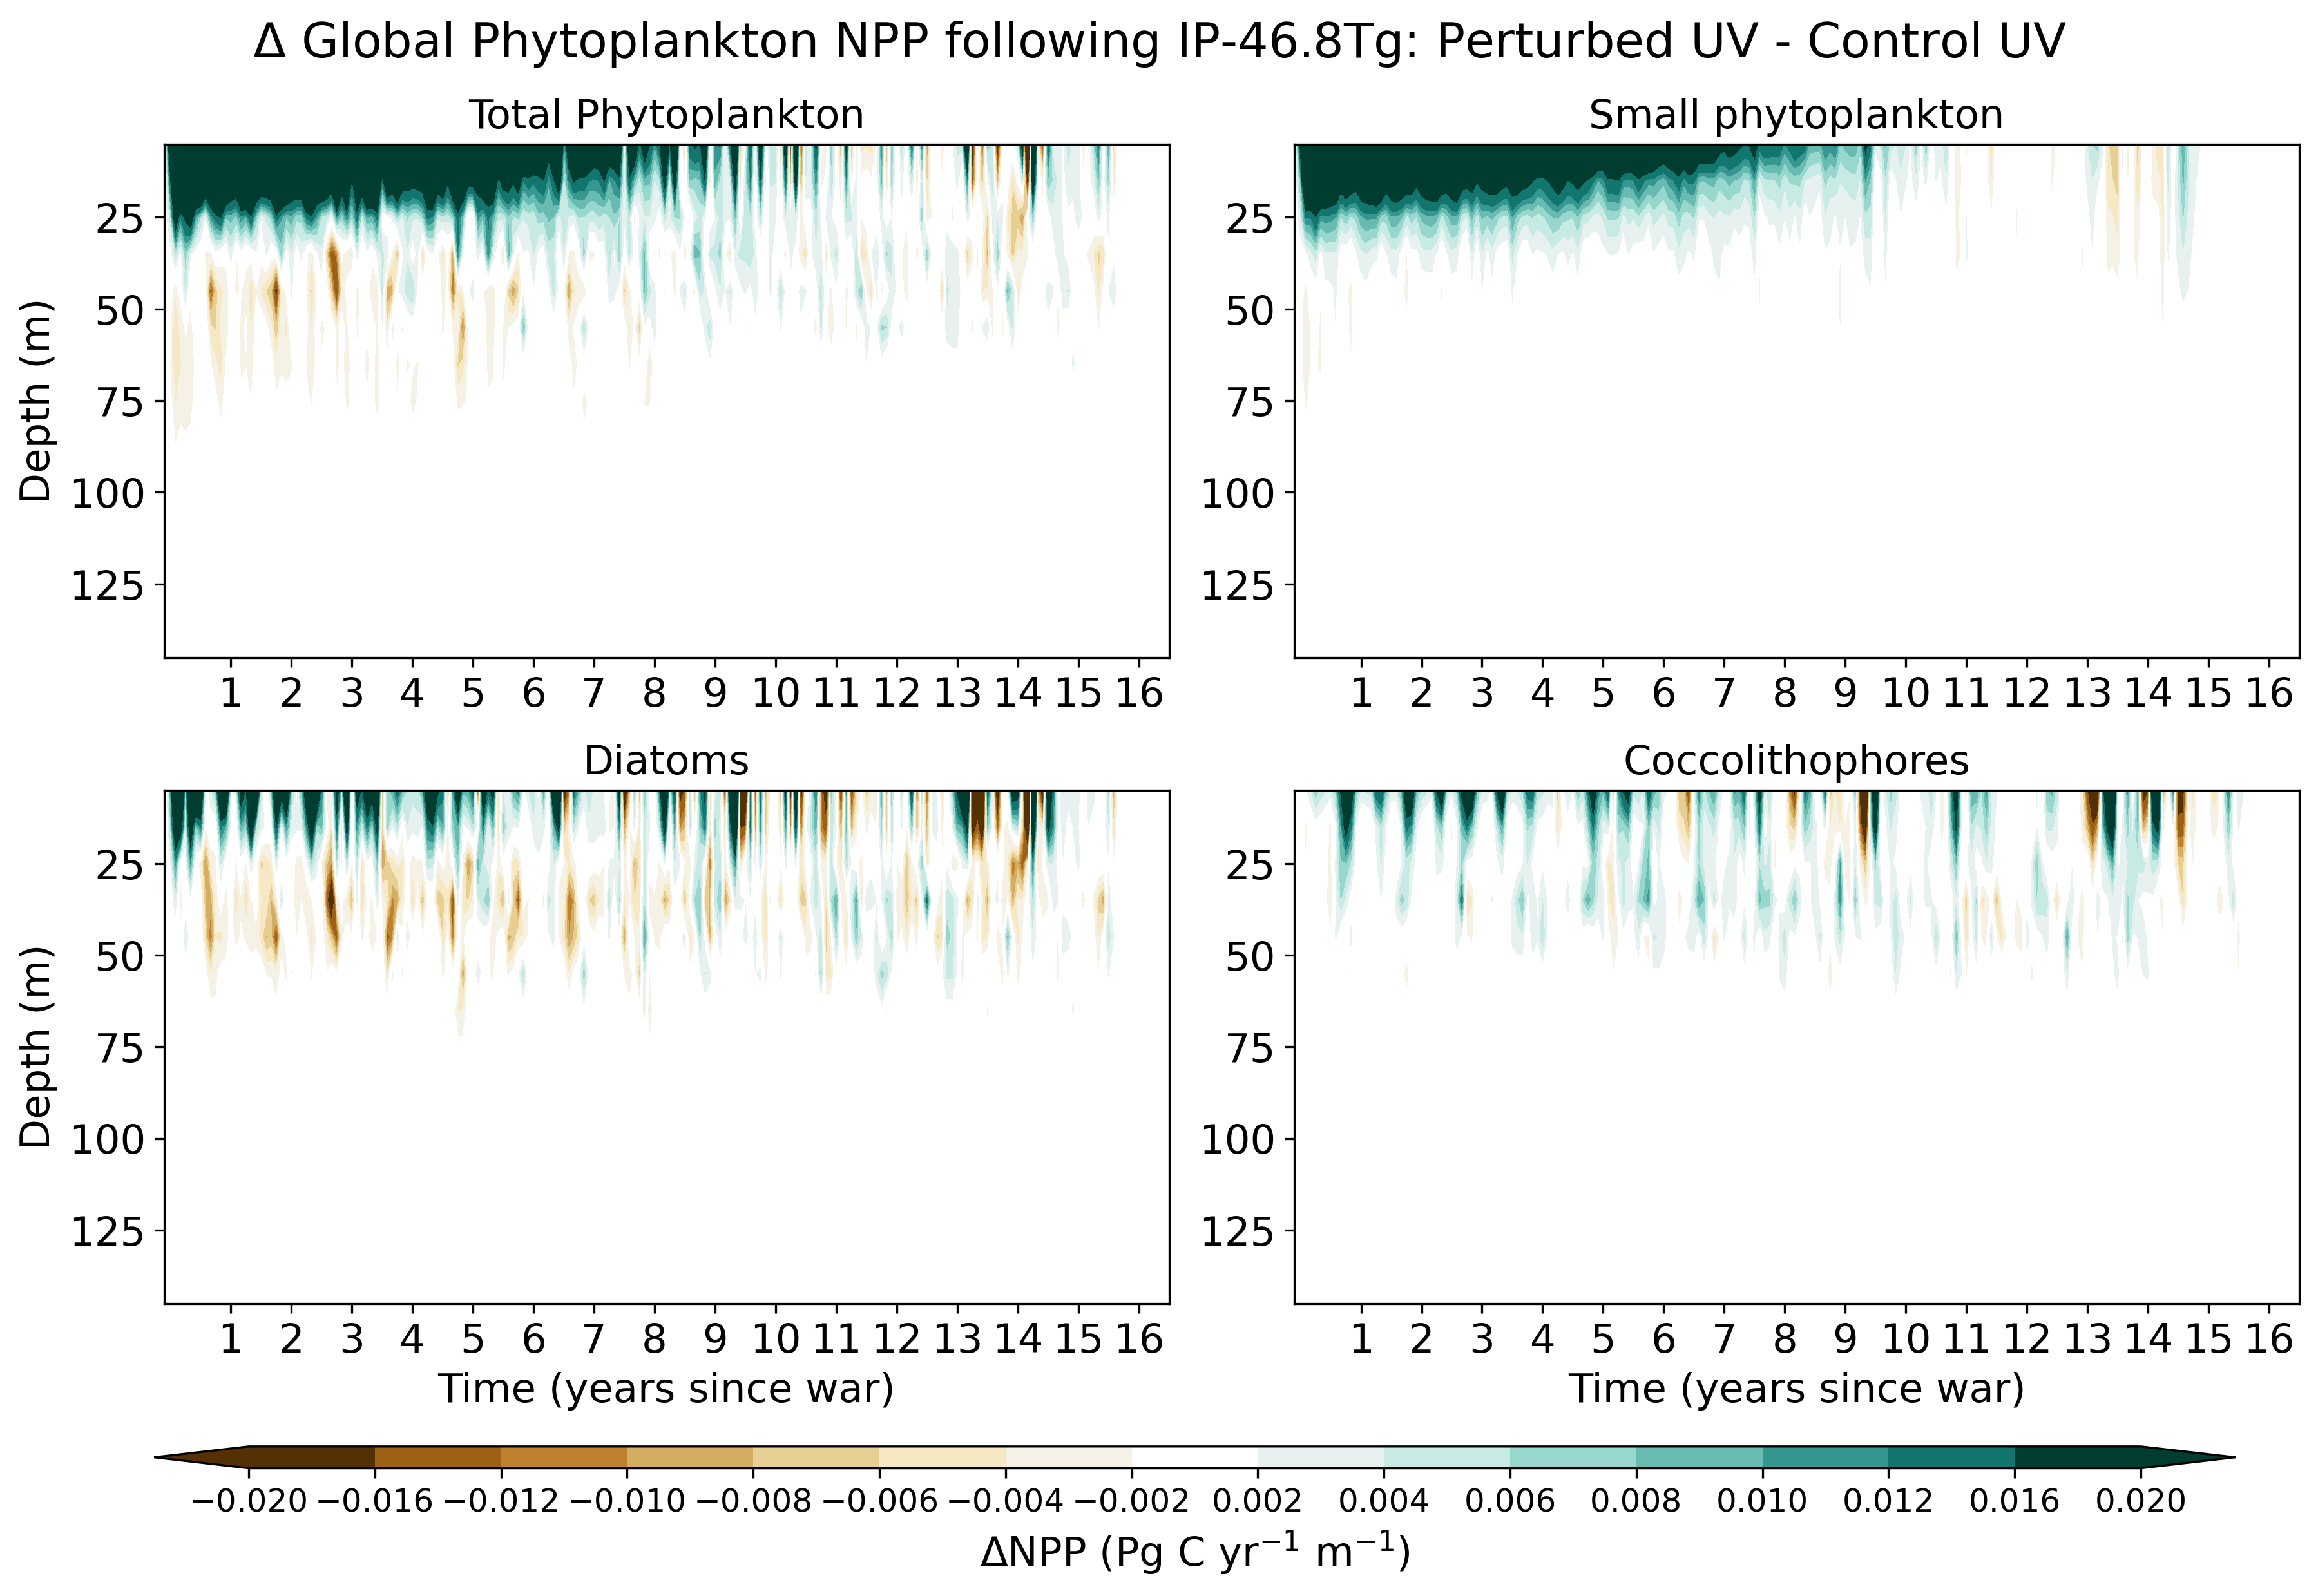

In [4]:





def get_colors(string,num,add_white = -1):
    #from pylab import *; 
    cmap = cm.get_cmap(string, num)    # PiYG
    colors=[]
    for i in range(cmap.N):
        rgb = cmap(i)[:3] # will return rgba, we take only first 3 so we get rgb
        colors.append(str(matplotlib.colors.rgb2hex(rgb))) 
    if add_white != -1:
        colors.insert(add_white,'#FFFFFF')
    return colors


# ORIGINAL
boundaries_diff=[-30,-20,-10,-5,-2,2,5,10,20,30]
colors_diff = get_colors('seismic',10,add_white=5)
cmap_diff = mpl.colors.ListedColormap(colors_diff, "")

# 
boundaries_diff = np.array([-10,-8,-6,-5,-4,-3,-2,-1,1,2,3,4,5,6,8,10])*2e-3
colors_diff = get_colors('BrBG',16,add_white=8)
cmap_diff = mpl.colors.ListedColormap(colors_diff, "")


# REGULAR - NOUV 
REGULAR_CASE='fosi_ip_46p8_01_alluv'
NOUV_CASE='fosi_ip_46p8_01_ctluv'
ALLUV_CASE='fosi_ip_46p8_01_alluv'
CTLUV_CASE='fosi_ip_46p8_01_ctluv'


var='photoC_TOT'

SUPTITLE_FONTSIZE=18
TITLE_FONTSIZE=15
YLABEL_FONTSIZE=15
XLABEL_FONTSIZE=15
COLORBARLABEL_FONTSIZE=15
COLORBARTICK_FONTSIZE=12

if True:
    # plot difference
    ALLUV = np.array(data[ALLUV_CASE][var])[0:NMONTHS] # has all uv radiation
    CTLUV= np.array(data[CTLUV_CASE][var])[0:NMONTHS] # has only control uv radiation
    diff = ALLUV - CTLUV  # co2 pulse - regular 
    if False:
        diff = diff * CTLUV**-1 * 100
        
    unit_factor = 12*1e-2*1e-3 *86400
    #unit_factor=1
    plt.close('all')
    num=1
    fig = plt.figure(figsize=(12.1,7.5),facecolor='white')
    #fig.suptitle('$\Delta$ Phytoplankton NPP (Biome 17 - Southern Ocean Ice) following UR-150Tg: \nPerturbed UV - Control UV',fontsize=SUPTITLE_FONTSIZE)
    fig.suptitle('$\Delta$ Global Phytoplankton NPP following IP-46.8Tg: Perturbed UV - Control UV',fontsize=SUPTITLE_FONTSIZE)
    gs = fig.add_gridspec(2, 2)
    n1 = 0
    n2 = NMONTHS
    offset = -5 * (1/12.0)
    # photoC_TOT
    var='photoC_TOT'
    ALLUV = np.array(data[ALLUV_CASE][var])[n1:n2] # co2 pulse
    CTLUV= np.array(data[CTLUV_CASE][var])[n1:n2] # normal
    diff = ALLUV - CTLUV  # co2 pulse - regular 
    #diff = diff * REGULAR**-1 * 100
    time=np.linspace(1,len(diff),len(diff))* (1/12.0) + offset
    
    ax1=fig.add_subplot(gs[0,0],facecolor='white')
    ax1.set_title('Total Phytoplankton',fontsize=TITLE_FONTSIZE)
    pc1 = ax1.contourf(time,z_t_150m,diff.T,cmap=cmap_diff,levels=boundaries_diff,extend='both')
    ax1.set_ylim((z_t_150m[-1],z_t_150m[0]))
    
    var='photoC_sp'
    ALLUV = np.array(data[ALLUV_CASE][var])[n1:n2] # co2 pulse
    CTLUV= np.array(data[CTLUV_CASE][var])[n1:n2] # normal
    diff = ALLUV - CTLUV  # co2 pulse - regular 
    #diff = diff * REGULAR**-1 * 100
    
    ax2=fig.add_subplot(gs[0,1],facecolor='white')
    ax2.set_title('Small phytoplankton',fontsize=TITLE_FONTSIZE)
    pc2 = ax2.contourf(time,z_t_150m,diff.T,cmap=cmap_diff,levels=boundaries_diff,extend='both')
    ax2.set_ylim((z_t_150m[-1],z_t_150m[0]))

    var='photoC_diat'
    ALLUV = np.array(data[ALLUV_CASE][var])[n1:n2] # co2 pulse
    CTLUV= np.array(data[CTLUV_CASE][var])[n1:n2] # normal
    diff = ALLUV - CTLUV  # co2 pulse - regular 
    #diff = diff * REGULAR**-1 * 100
    
    ax3=fig.add_subplot(gs[1,0],facecolor='white')
    ax3.set_title('Diatoms',fontsize=TITLE_FONTSIZE)
    pc3 = ax3.contourf(time,z_t_150m,diff.T,cmap=cmap_diff,levels=boundaries_diff,extend='both')
    ax3.set_ylim((z_t_150m[-1],z_t_150m[0]))

    var='photoC_cocco'
    ALLUV = np.array(data[ALLUV_CASE][var])[n1:n2] # co2 pulse
    CTLUV= np.array(data[CTLUV_CASE][var])[n1:n2] # normal
    diff = ALLUV - CTLUV  # co2 pulse - regular 
    #diff = diff * REGULAR**-1 * 100
    
    ax4=fig.add_subplot(gs[1,1],facecolor='white')
    ax4.set_title('Coccolithophores',fontsize=TITLE_FONTSIZE)
    pc4 = ax4.contourf(time,z_t_150m,diff.T,cmap=cmap_diff,levels=boundaries_diff,extend='both')
    ##pc4_contour = ax4.contour(time,z_t_150m,diff.T,colors='k',levels=[50,100,150,200],linewidths=0.5)
    #ax4.clabel(pc4_contour,[50,100,150,200],fontsize=10)
    ax4.set_ylim((z_t_150m[-1],z_t_150m[0]))


    ax1.set_ylabel('Depth (m)',fontsize=YLABEL_FONTSIZE); 
    ax3.set_ylabel('Depth (m)',fontsize=YLABEL_FONTSIZE)
    ax3.set_xlabel('Time (years since war)',fontsize=XLABEL_FONTSIZE)
    ax4.set_xlabel('Time (years since war)',fontsize=XLABEL_FONTSIZE)
    for ax in [ax1,ax2,ax3,ax4]:
        print(ax)
        ax.set_xticks([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],('1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20'),fontsize=XLABEL_FONTSIZE); 
        ax.set_xlim([-0.1,16.5])
        ax.tick_params(axis='y',labelsize=YLABEL_FONTSIZE)
    
    position = fig.add_axes([0.07,-0.02,0.89,0.015])
    cbar1 = fig.colorbar(pc1,extend='both',cax=position,orientation='horizontal',norm=mpl.colors.BoundaryNorm(boundaries_diff,ncolors=len(boundaries_diff)-1,clip=False))
    cbar1.ax.tick_params(labelsize=COLORBARTICK_FONTSIZE)
    cbar1.set_ticks(boundaries_diff)
    cbar1.set_label('$\Delta$NPP (Pg C yr$^{-1}$ m$^{-1}$)',fontsize=COLORBARLABEL_FONTSIZE); fig.tight_layout()
    plt.savefig('/projects/joco6825/imgs/random124124.png',bbox_inches='tight'); plt.show()

    

In [5]:
# Figure S7: repeat S6 but for IP-5Tg



data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'


these_cases=['fosi_ip_5tg_01_alluv','fosi_ip_5tg_01_ctluv']
these_variables=['photoC_TOT','photoC_sp','photoC_diat','photoC_cocco']

files={}
for case in these_cases: # these files need to be processed and in their proper place
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.000502-*.nc'))[:]

        


In [7]:
example_file=files[case][VAR][0]           
                    
extract = nc4.Dataset(example_file,'r')
TAREA = extract.variables['TAREA'][0]*(100**-2)
z_t_150m = extract.variables['z_t_150m'][:]*(0.01)
dz = extract.variables['dz'][0]*(0.01) # this should be DELTA Z not z_t_150m
dz = dz*0 + 1 
TLAT = extract.variables['TLAT'][:]


extract_biome=nc4.Dataset('/projects/joco6825/fay_biomes_POP.nc','r')
biome_mask = extract_biome.variables['fay_biomes'][:].T
TAREA_biome6 = np.array(TAREA)

#TAREA_biome6[biome_mask != 16] = 0.0 # set TAREA to 0 when biome_mask is 6 (eastern equatorial Pacific)
#TAREA_biome6[TAREA_biome6>9e35] = 0.0 # in case fill values fail to be registered


threshold_date = datetime.strptime('0005-01-01', "%Y-%m-%d")


scale_factor = (1000**-1) * (12.011) * (86400) * (365) * (1e-15)

VARIABLES=['photoC_TOT','photoC_sp','photoC_diat','photoC_cocco']
#VARIABLES=['photoC_TOT']
if True:
 data={};
 for case in these_cases:
     print(case)
     data[case]={}
     for VAR in VARIABLES:
         print(VAR)
         data[case][VAR]=np.zeros((NMONTHS,len(z_t_150m)))
         mo=0
         for fi in files[case][VAR][:]:
             extract = nc4.Dataset(fi,'r')
             dates = extract.variables['time'][:]
             for t in range(len(dates)):
                 # convert to datetime days since 0000-01-01 00:00:00
                 result_date = convert_days_to_date(dates[t])
                 if result_date > threshold_date: # put them on the same time axis
                     tempdata = extract.variables[VAR][t]
                     for lev in range(len(z_t_150m)):
                         data[case][VAR][mo][lev] = np.nansum(tempdata[lev]*TAREA_biome6*dz[lev]*scale_factor)#,weights=TAREA_biome6)
                     mo=mo+1 
                    
                    
print('DONE')

fosi_ip_5tg_01_alluv
photoC_TOT
photoC_sp
photoC_diat
photoC_cocco
fosi_ip_5tg_01_ctluv
photoC_TOT
photoC_sp
photoC_diat
photoC_cocco
DONE


/tmp/ipykernel_3694040/3741793962.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(string, num)    # PiYG
/tmp/ipykernel_3694040/3741793962.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  cbar1.set_label('$\Delta$NPP (Pg C yr$^{-1}$)',fontsize=COLORBARLABEL_FONTSIZE); fig.tight_layout()


Axes(0.125,0.53;0.352273x0.35)
Axes(0.547727,0.53;0.352273x0.35)
Axes(0.125,0.11;0.352273x0.35)
Axes(0.547727,0.11;0.352273x0.35)


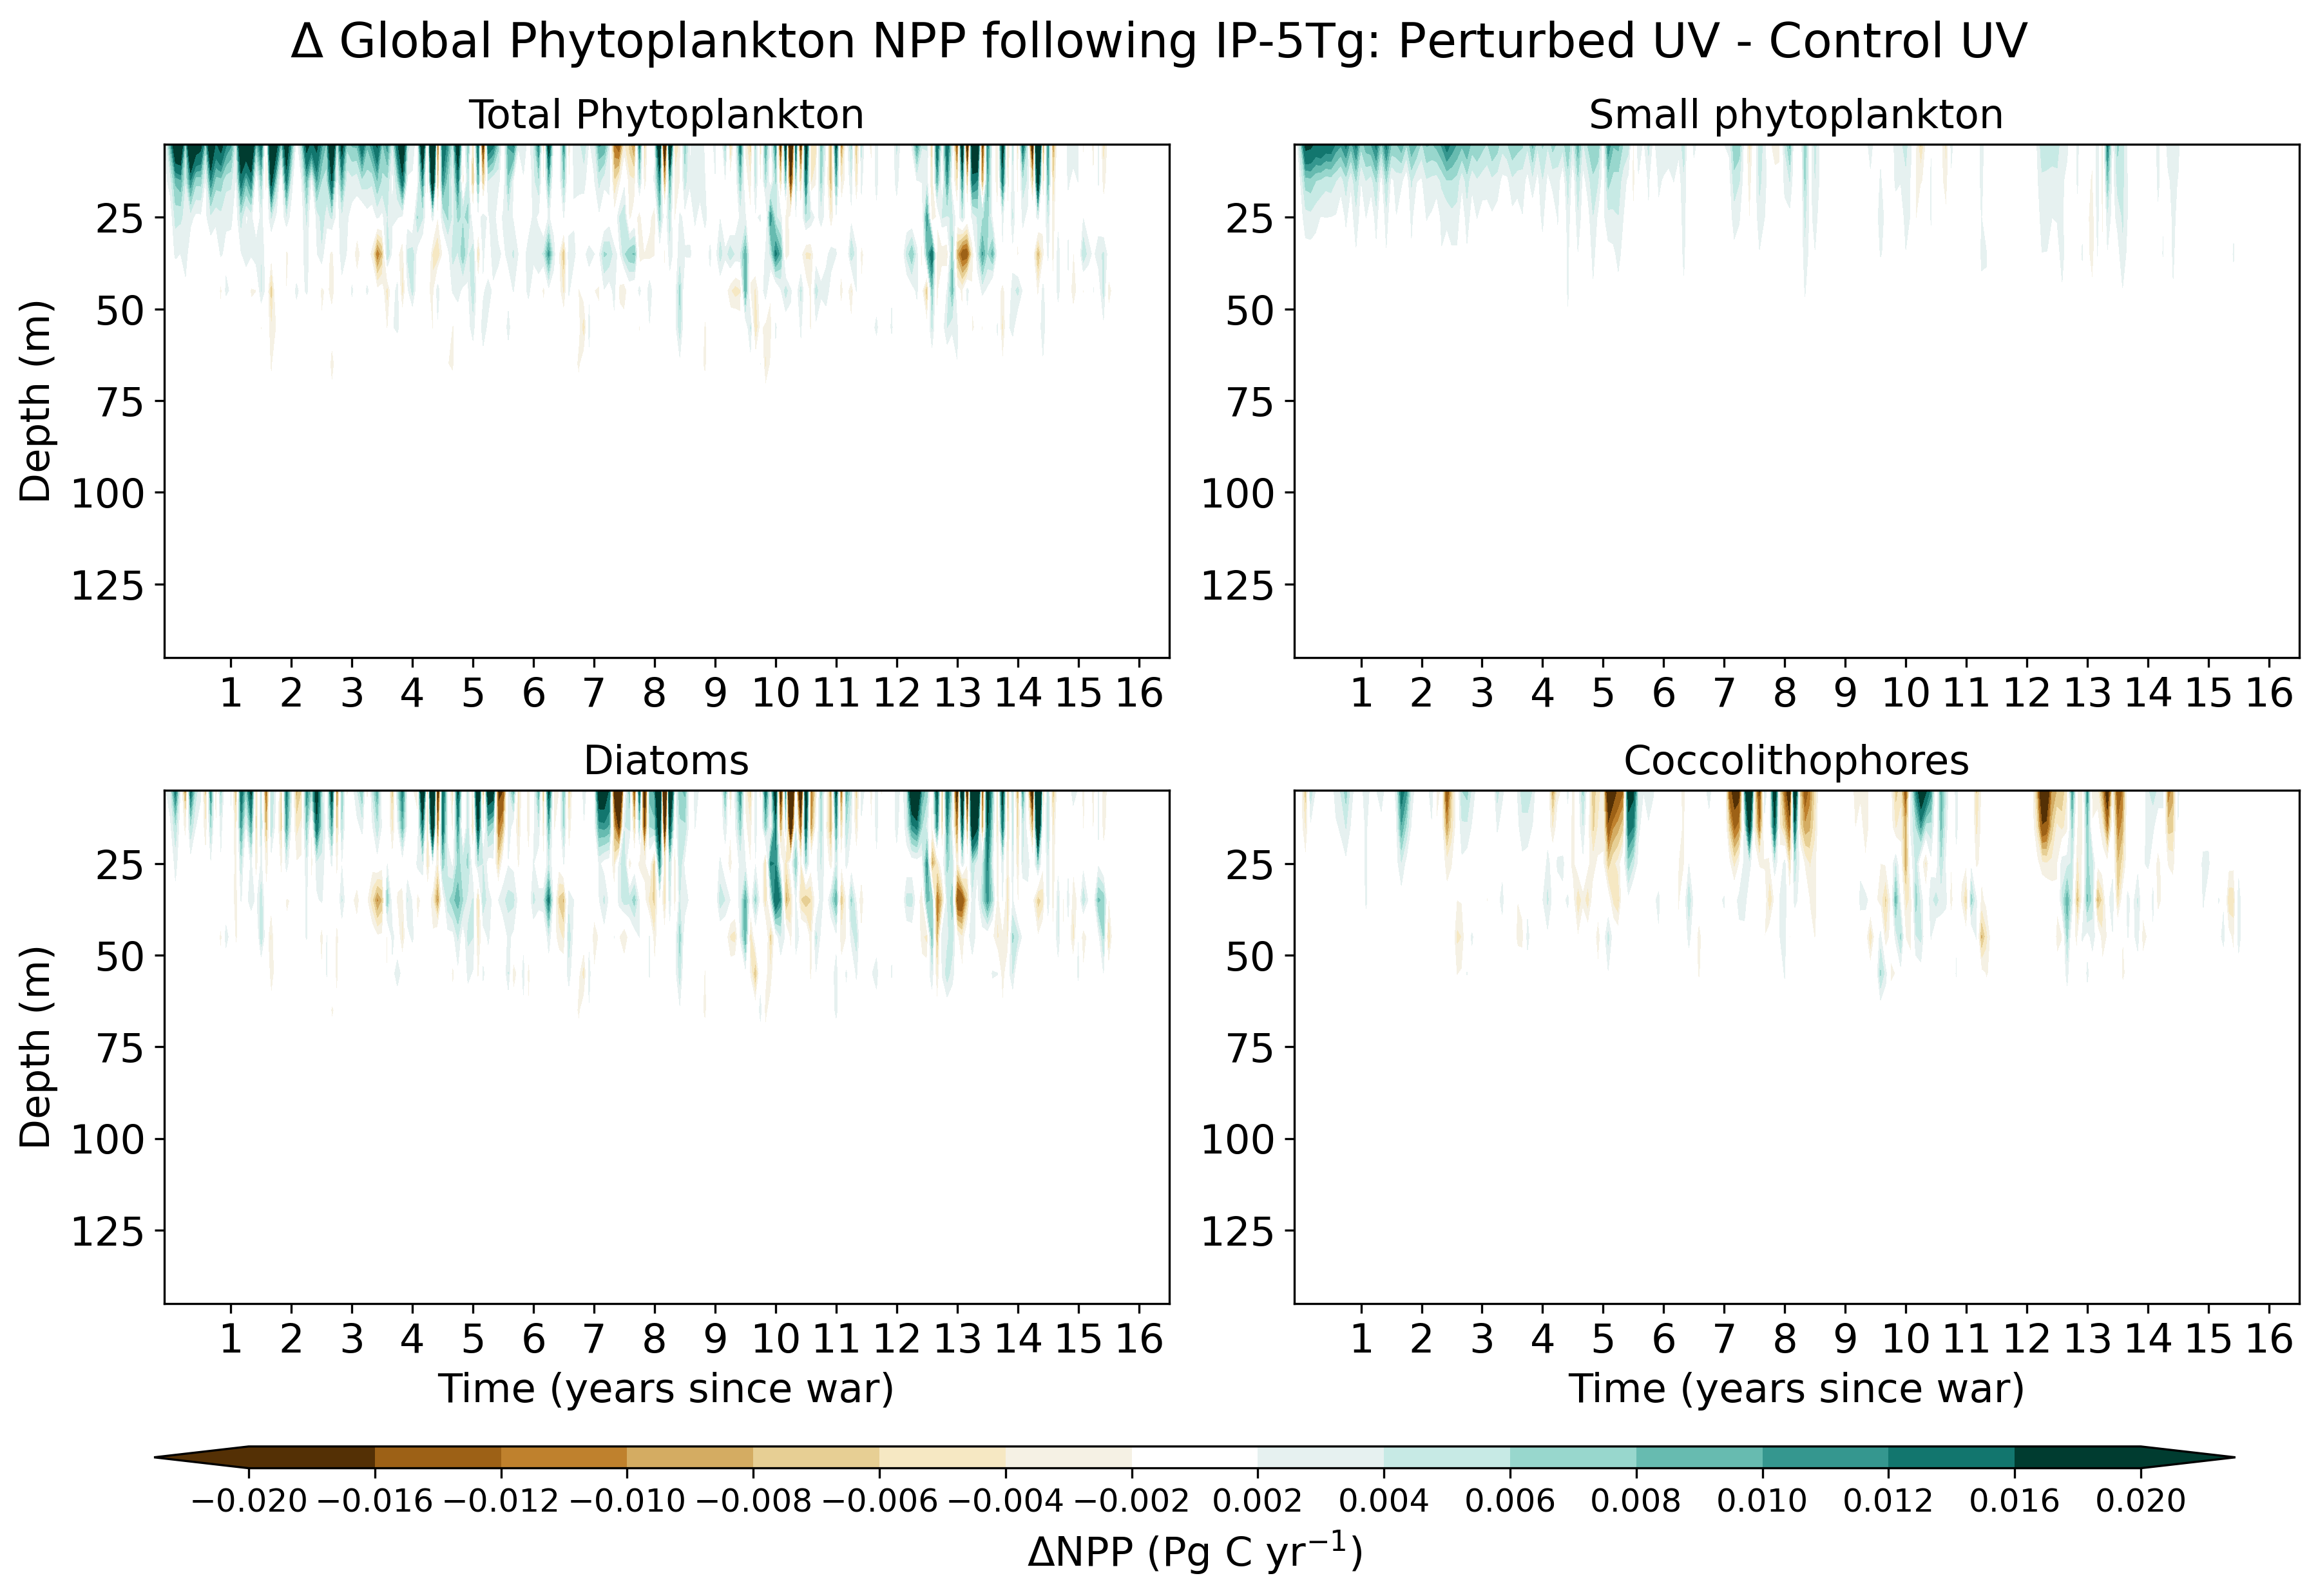

In [8]:

def get_colors(string,num,add_white = -1):
    #from pylab import *; 
    cmap = cm.get_cmap(string, num)    # PiYG
    colors=[]
    for i in range(cmap.N):
        rgb = cmap(i)[:3] # will return rgba, we take only first 3 so we get rgb
        colors.append(str(matplotlib.colors.rgb2hex(rgb))) 
    if add_white != -1:
        colors.insert(add_white,'#FFFFFF')
    return colors


# ORIGINAL
boundaries_diff=[-30,-20,-10,-5,-2,2,5,10,20,30]
colors_diff = get_colors('seismic',10,add_white=5)
cmap_diff = mpl.colors.ListedColormap(colors_diff, "")

# 
boundaries_diff = np.array([-10,-8,-6,-5,-4,-3,-2,-1,1,2,3,4,5,6,8,10])*2e-3
colors_diff = get_colors('BrBG',16,add_white=8)
cmap_diff = mpl.colors.ListedColormap(colors_diff, "")


# REGULAR - NOUV 
REGULAR_CASE='fosi_ip_5tg_01_alluv'
NOUV_CASE='fosi_ip_5tg_01_ctluv'
ALLUV_CASE='fosi_ip_5tg_01_alluv'
CTLUV_CASE='fosi_ip_5tg_01_ctluv'


var='photoC_TOT'

SUPTITLE_FONTSIZE=18
TITLE_FONTSIZE=15
YLABEL_FONTSIZE=15
XLABEL_FONTSIZE=15
COLORBARLABEL_FONTSIZE=15
COLORBARTICK_FONTSIZE=12

if True:
    # plot difference
    ALLUV = np.array(data[ALLUV_CASE][var])[0:NMONTHS] # has all uv radiation
    CTLUV= np.array(data[CTLUV_CASE][var])[0:NMONTHS] # has only control uv radiation
    diff = ALLUV - CTLUV  # co2 pulse - regular 
    if False:
        diff = diff * CTLUV**-1 * 100
        
    unit_factor = 12*1e-2*1e-3 *86400
    #unit_factor=1
    plt.close('all')
    num=1
    fig = plt.figure(figsize=(12.1,7.5),facecolor='white')
    #fig.suptitle('$\Delta$ Phytoplankton NPP (Biome 17 - Southern Ocean Ice) following UR-150Tg: \nPerturbed UV - Control UV',fontsize=SUPTITLE_FONTSIZE)
    fig.suptitle('$\Delta$ Global Phytoplankton NPP following IP-5Tg: Perturbed UV - Control UV',fontsize=SUPTITLE_FONTSIZE)
    gs = fig.add_gridspec(2, 2)
    n1 = 0
    n2 = NMONTHS
    offset = -5 * (1/12.0)
    # photoC_TOT
    var='photoC_TOT'
    ALLUV = np.array(data[ALLUV_CASE][var])[n1:n2] # co2 pulse
    CTLUV= np.array(data[CTLUV_CASE][var])[n1:n2] # normal
    diff = ALLUV - CTLUV  # co2 pulse - regular 
    #diff = diff * REGULAR**-1 * 100
    time=np.linspace(1,len(diff),len(diff))* (1/12.0) + offset
    
    ax1=fig.add_subplot(gs[0,0],facecolor='white')
    ax1.set_title('Total Phytoplankton',fontsize=TITLE_FONTSIZE)
    pc1 = ax1.contourf(time,z_t_150m,diff.T,cmap=cmap_diff,levels=boundaries_diff,extend='both')
    ax1.set_ylim((z_t_150m[-1],z_t_150m[0]))
    
    var='photoC_sp'
    ALLUV = np.array(data[ALLUV_CASE][var])[n1:n2] # co2 pulse
    CTLUV= np.array(data[CTLUV_CASE][var])[n1:n2] # normal
    diff = ALLUV - CTLUV  # co2 pulse - regular 
    #diff = diff * REGULAR**-1 * 100
    
    ax2=fig.add_subplot(gs[0,1],facecolor='white')
    ax2.set_title('Small phytoplankton',fontsize=TITLE_FONTSIZE)
    pc2 = ax2.contourf(time,z_t_150m,diff.T,cmap=cmap_diff,levels=boundaries_diff,extend='both')
    ax2.set_ylim((z_t_150m[-1],z_t_150m[0]))

    var='photoC_diat'
    ALLUV = np.array(data[ALLUV_CASE][var])[n1:n2] # co2 pulse
    CTLUV= np.array(data[CTLUV_CASE][var])[n1:n2] # normal
    diff = ALLUV - CTLUV  # co2 pulse - regular 
    #diff = diff * REGULAR**-1 * 100
    
    ax3=fig.add_subplot(gs[1,0],facecolor='white')
    ax3.set_title('Diatoms',fontsize=TITLE_FONTSIZE)
    pc3 = ax3.contourf(time,z_t_150m,diff.T,cmap=cmap_diff,levels=boundaries_diff,extend='both')
    ax3.set_ylim((z_t_150m[-1],z_t_150m[0]))

    var='photoC_cocco'
    ALLUV = np.array(data[ALLUV_CASE][var])[n1:n2] # co2 pulse
    CTLUV= np.array(data[CTLUV_CASE][var])[n1:n2] # normal
    diff = ALLUV - CTLUV  # co2 pulse - regular 
    #diff = diff * REGULAR**-1 * 100
    
    ax4=fig.add_subplot(gs[1,1],facecolor='white')
    ax4.set_title('Coccolithophores',fontsize=TITLE_FONTSIZE)
    pc4 = ax4.contourf(time,z_t_150m,diff.T,cmap=cmap_diff,levels=boundaries_diff,extend='both')
    ##pc4_contour = ax4.contour(time,z_t_150m,diff.T,colors='k',levels=[50,100,150,200],linewidths=0.5)
    #ax4.clabel(pc4_contour,[50,100,150,200],fontsize=10)
    ax4.set_ylim((z_t_150m[-1],z_t_150m[0]))


    ax1.set_ylabel('Depth (m)',fontsize=YLABEL_FONTSIZE); 
    ax3.set_ylabel('Depth (m)',fontsize=YLABEL_FONTSIZE)
    ax3.set_xlabel('Time (years since war)',fontsize=XLABEL_FONTSIZE)
    ax4.set_xlabel('Time (years since war)',fontsize=XLABEL_FONTSIZE)
    for ax in [ax1,ax2,ax3,ax4]:
        print(ax)
        ax.set_xticks([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],('1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20'),fontsize=XLABEL_FONTSIZE); 
        ax.set_xlim([-0.1,16.5])
        ax.tick_params(axis='y',labelsize=YLABEL_FONTSIZE)
    
    position = fig.add_axes([0.07,-0.02,0.89,0.015])
    cbar1 = fig.colorbar(pc1,extend='both',cax=position,orientation='horizontal',norm=mpl.colors.BoundaryNorm(boundaries_diff,ncolors=len(boundaries_diff)-1,clip=False))
    cbar1.ax.tick_params(labelsize=COLORBARTICK_FONTSIZE)
    cbar1.set_ticks(boundaries_diff)
    cbar1.set_label('$\Delta$NPP (Pg C yr$^{-1}$)',fontsize=COLORBARLABEL_FONTSIZE); fig.tight_layout()
    plt.show()

    
    